## Step 1: Project Summary

In [30]:
"""
In the competitive telecommunications industry, customer churn is a critical challenge. 
This project aims to predict customer churn for SyriaTel using predictive modeling and data analysis. 
By identifying patterns in customer behavior, the models developed will help SyriaTel take proactive measures 
to improve customer retention and reduce attrition rates.
"""

'\nIn the competitive telecommunications industry, customer churn is a critical challenge. \nThis project aims to predict customer churn for SyriaTel using predictive modeling and data analysis. \nBy identifying patterns in customer behavior, the models developed will help SyriaTel take proactive measures \nto improve customer retention and reduce attrition rates.\n'

## Step 2: Data

In [31]:
# Importing necessary libraries
import pandas as pd
# Loading the dataset
data = pd.read_csv("Churn in Telecoms dataset.csv")
# Checking first 5 rows
data.head()


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [32]:
data['churn'].value_counts()

False    2850
True      483
Name: churn, dtype: int64

In [33]:
# Dropping irrelevant columns for prediction analysis
data.drop(['state', 'area code', 'phone number'], axis=1, inplace=True)

In [34]:
# Selecting relevant columns for modeling
selected_columns = ['account length', 'international plan', 'voice mail plan',
                    'number vmail messages', 'total day minutes', 'total day calls',
                    'total day charge', 'total eve minutes', 'total eve calls',
                    'total eve charge', 'total night minutes', 'total night calls',
                    'total night charge', 'total intl minutes', 'total intl calls',
                    'total intl charge', 'customer service calls', 'churn']
data = data[selected_columns]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   account length          3333 non-null   int64  
 1   international plan      3333 non-null   object 
 2   voice mail plan         3333 non-null   object 
 3   number vmail messages   3333 non-null   int64  
 4   total day minutes       3333 non-null   float64
 5   total day calls         3333 non-null   int64  
 6   total day charge        3333 non-null   float64
 7   total eve minutes       3333 non-null   float64
 8   total eve calls         3333 non-null   int64  
 9   total eve charge        3333 non-null   float64
 10  total night minutes     3333 non-null   float64
 11  total night calls       3333 non-null   int64  
 12  total night charge      3333 non-null   float64
 13  total intl minutes      3333 non-null   float64
 14  total intl calls        3333 non-null   

In [35]:
# Displaying a sample of the dataset
sample_data = data.sample(5)
print("Sample Data:")
sample_data

Sample Data:


,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
1847,54,no,yes,39,143.9,73,24.46,210.3,117,17.88,129.2,117,5.81,12.5,8,3.38,2,False
3020,127,no,yes,23,182.0,80,30.94,216.1,85,18.37,156.9,82,7.06,9.8,4,2.65,1,False
1619,149,no,no,0,119.2,88,20.26,168.3,110,14.31,204.7,119,9.21,12.2,6,3.29,4,True
3060,94,no,no,0,212.1,98,36.06,189.4,89,16.10,352.2,95,15.85,8.4,5,2.27,3,False
3143,104,no,no,0,109.1,141,18.55,187.1,140,15.90,216.6,100,9.75,10.0,4,2.70,3,False


## Step 3: Data Dictionary

In [37]:
# Information about columns and their types
data_info = data.dtypes

# Descriptive statistics for numerical columns
numerical_summary = data.describe().transpose()

# Summarizing categorical columns
categorical_columns = data.select_dtypes(include=['object', 'bool']).columns
categorical_summary = {col: data[col].value_counts().to_dict() for col in categorical_columns}


In [39]:
print("Data Dictionary:")
print("Column Types:", data_info)
print("Numerical Summary:", numerical_summary)
print("Categorical Summary:", categorical_summary)

Data Dictionary:
Column Types: account length              int64
international plan         object
voice mail plan            object
number vmail messages       int64
total day minutes         float64
total day calls             int64
total day charge          float64
total eve minutes         float64
total eve calls             int64
total eve charge          float64
total night minutes       float64
total night calls           int64
total night charge        float64
total intl minutes        float64
total intl calls            int64
total intl charge         float64
customer service calls      int64
churn                        bool
dtype: object
Numerical Summary:                          count        mean        std    min     25%     50%  \
account length          3333.0  101.064806  39.822106   1.00   74.00  101.00   
number vmail messages   3333.0    8.099010  13.688365   0.00    0.00    0.00   
total day minutes       3333.0  179.775098  54.467389   0.00  143.70  179.40   
tota

## Step 4: Exploratory Data Analysis (EDA)

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Focused features
selected_features = ['total day minutes', 'customer service calls', 'voice mail plan', 'international plan']

# Univariate statistics for selected features
univariate_stats = data[selected_features].describe(include='all').transpose()
print("Univariate Statistics:")
print(univariate_stats)

Univariate Statistics:
                         count unique  top  freq        mean        std  min  \
total day minutes       3333.0    NaN  NaN   NaN  179.775098  54.467389  0.0   
customer service calls  3333.0    NaN  NaN   NaN    1.562856   1.315491  0.0   
voice mail plan           3333      2   no  2411         NaN        NaN  NaN   
international plan        3333      2   no  3010         NaN        NaN  NaN   

                          25%    50%    75%    max  
total day minutes       143.7  179.4  216.4  350.8  
customer service calls    1.0    1.0    2.0    9.0  
voice mail plan           NaN    NaN    NaN    NaN  
international plan        NaN    NaN    NaN    NaN  


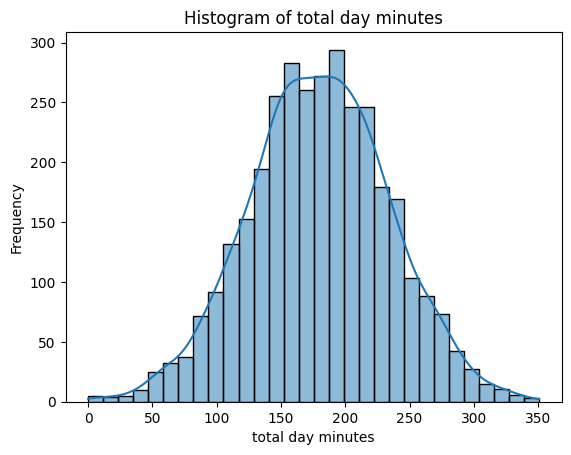

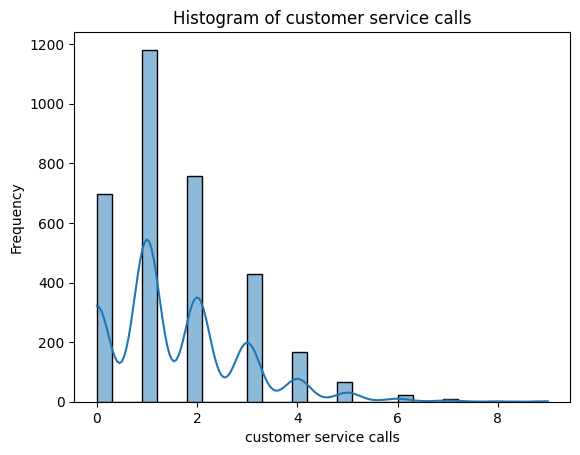

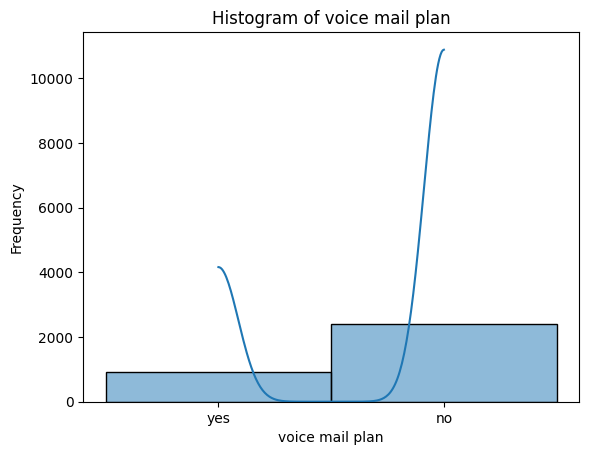

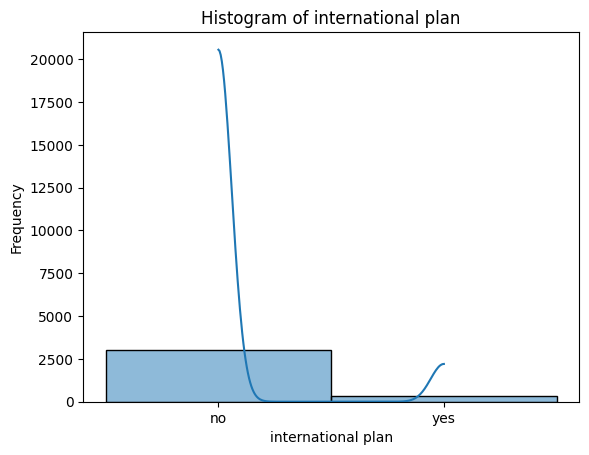

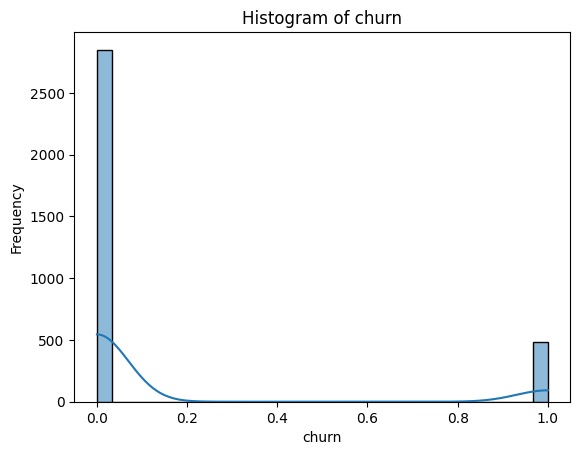

In [43]:
# Univariate visualizations
for feature in selected_features + ['churn']:
    sns.histplot(data[feature], kde=True, bins=30)
    plt.title(f"Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()


Chi-square Test for voice mail plan and churn:
Chi2: 34.13166001075673 p-value: 5.15063965903898e-09


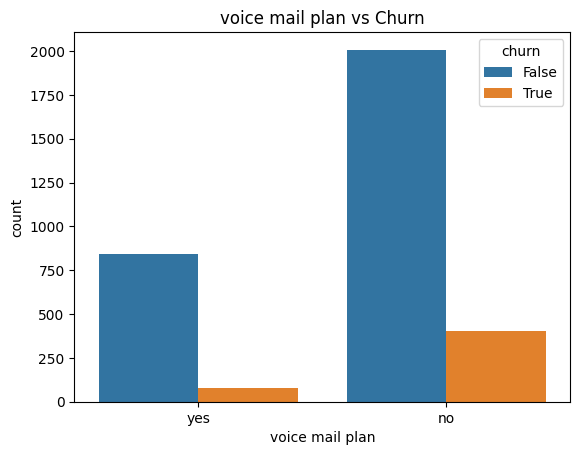

Chi-square Test for international plan and churn:
Chi2: 222.5657566499376 p-value: 2.4931077033159556e-50


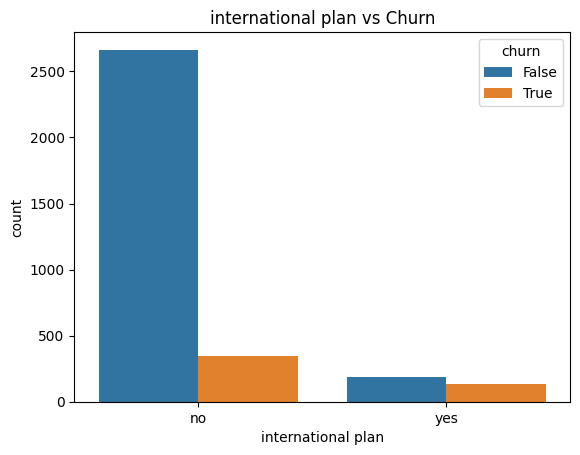

In [45]:
# Bivariate statistics and visualizations
from scipy.stats import chi2_contingency, ttest_ind

# Chi-square test for categorical features
for feature in ['voice mail plan', 'international plan']:
    contingency_table = pd.crosstab(data[feature], data['churn'])
    chi2, p, _, _ = chi2_contingency(contingency_table)
    print(f"Chi-square Test for {feature} and churn:")
    print("Chi2:", chi2, "p-value:", p)
    sns.countplot(x=feature, hue='churn', data=data)
    plt.title(f"{feature} vs Churn")
    plt.show()

Correlation between total day minutes and churn: 0.20515082926138956


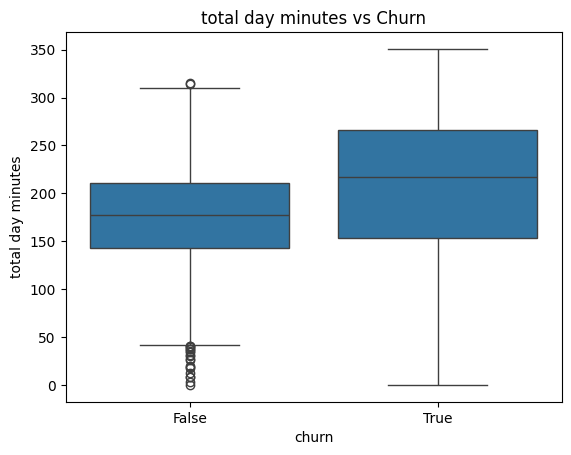

Correlation between customer service calls and churn: 0.2087499987837932


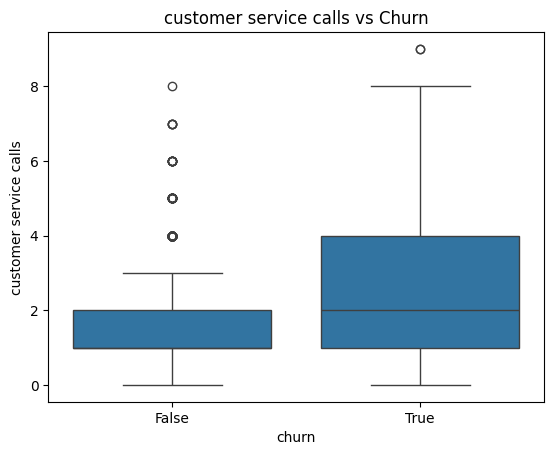

In [47]:
# Correlation for numeric features
for feature in ['total day minutes', 'customer service calls']:
    correlation = data[feature].corr(data['churn'].astype(int))
    print(f"Correlation between {feature} and churn:", correlation)
    sns.boxplot(x='churn', y=feature, data=data)
    plt.title(f"{feature} vs Churn")
    plt.show()

## Step 5: Data Cleaning Report

In [49]:
from sklearn.preprocessing import LabelEncoder
# Applying label encoding to binary columns
label_encoder = LabelEncoder()
data['churn'] = label_encoder.fit_transform(data['churn'])
data['international plan'] = label_encoder.fit_transform(data['international plan'])
data['voice mail plan'] = label_encoder.fit_transform(data['voice mail plan'])

In [51]:
data.head()

,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [53]:
# Creating boxplots for numerical columns
def create_boxplots(data, numerical_columns):
    fig, axs = plt.subplots(4, 4, figsize=(17, 10))
    for i, column in enumerate(numerical_columns):
        row = i // 4
        col = i % 4
        ax = axs[row, col]
        sns.boxplot(data[column], ax=ax)
        ax.set_title(f'{column}')
    plt.tight_layout()

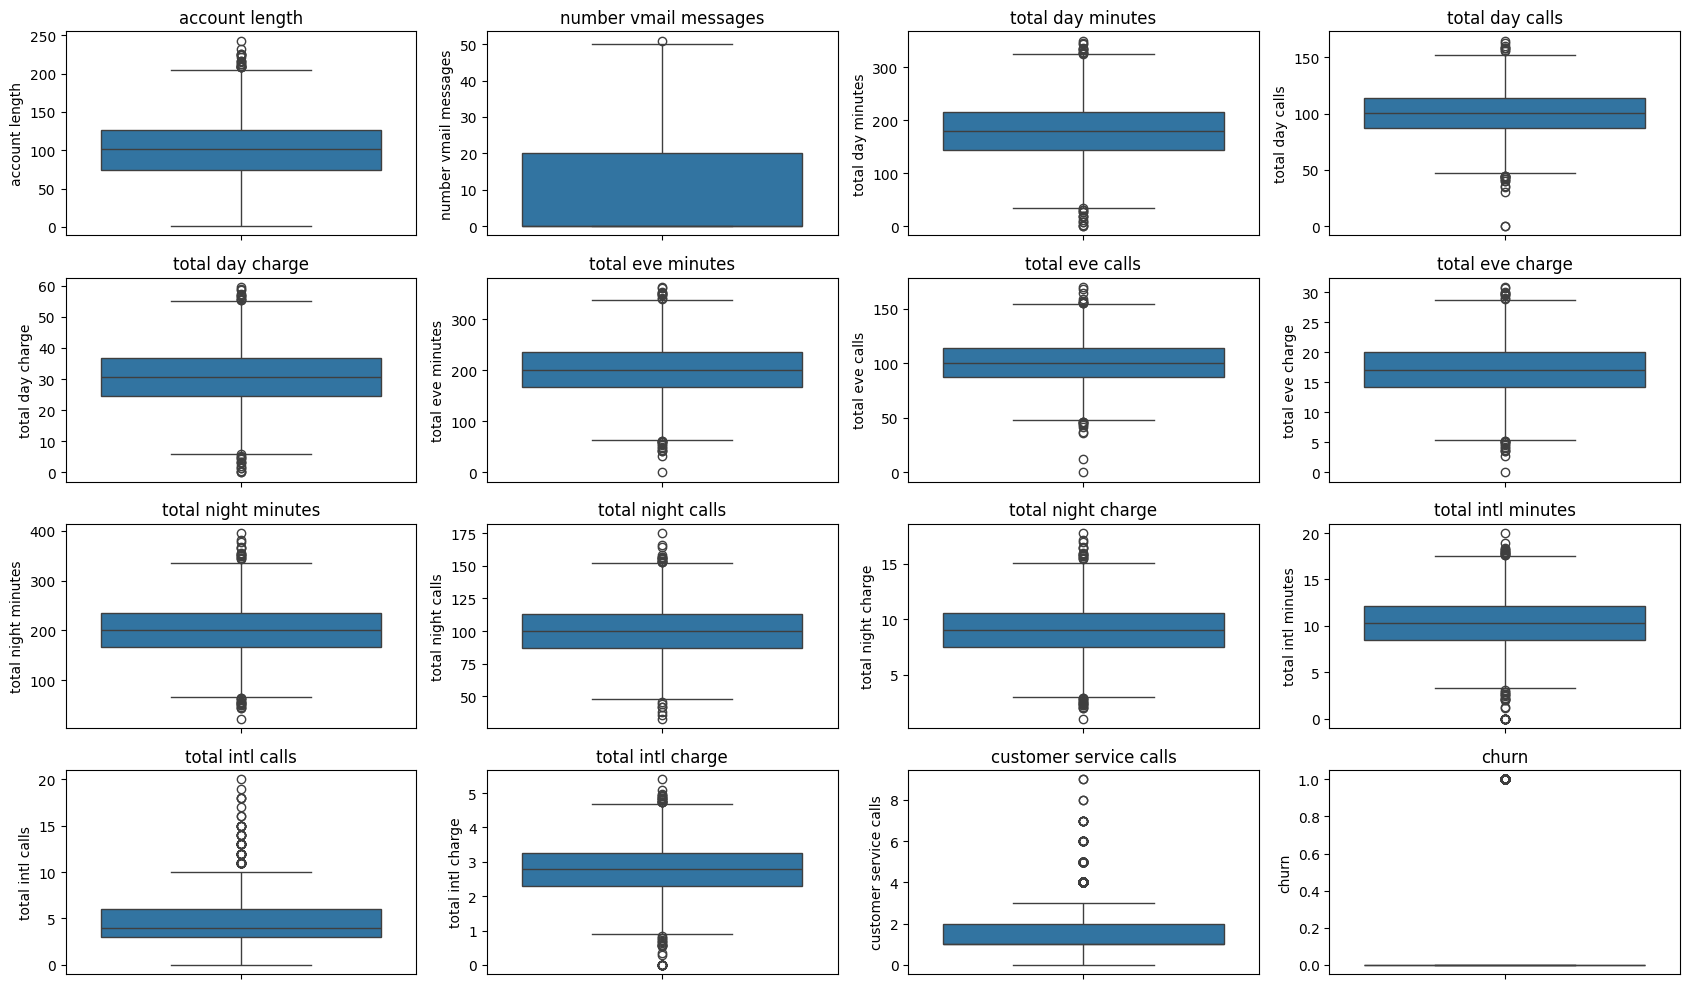

In [57]:
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
create_boxplots(data, numeric_columns)


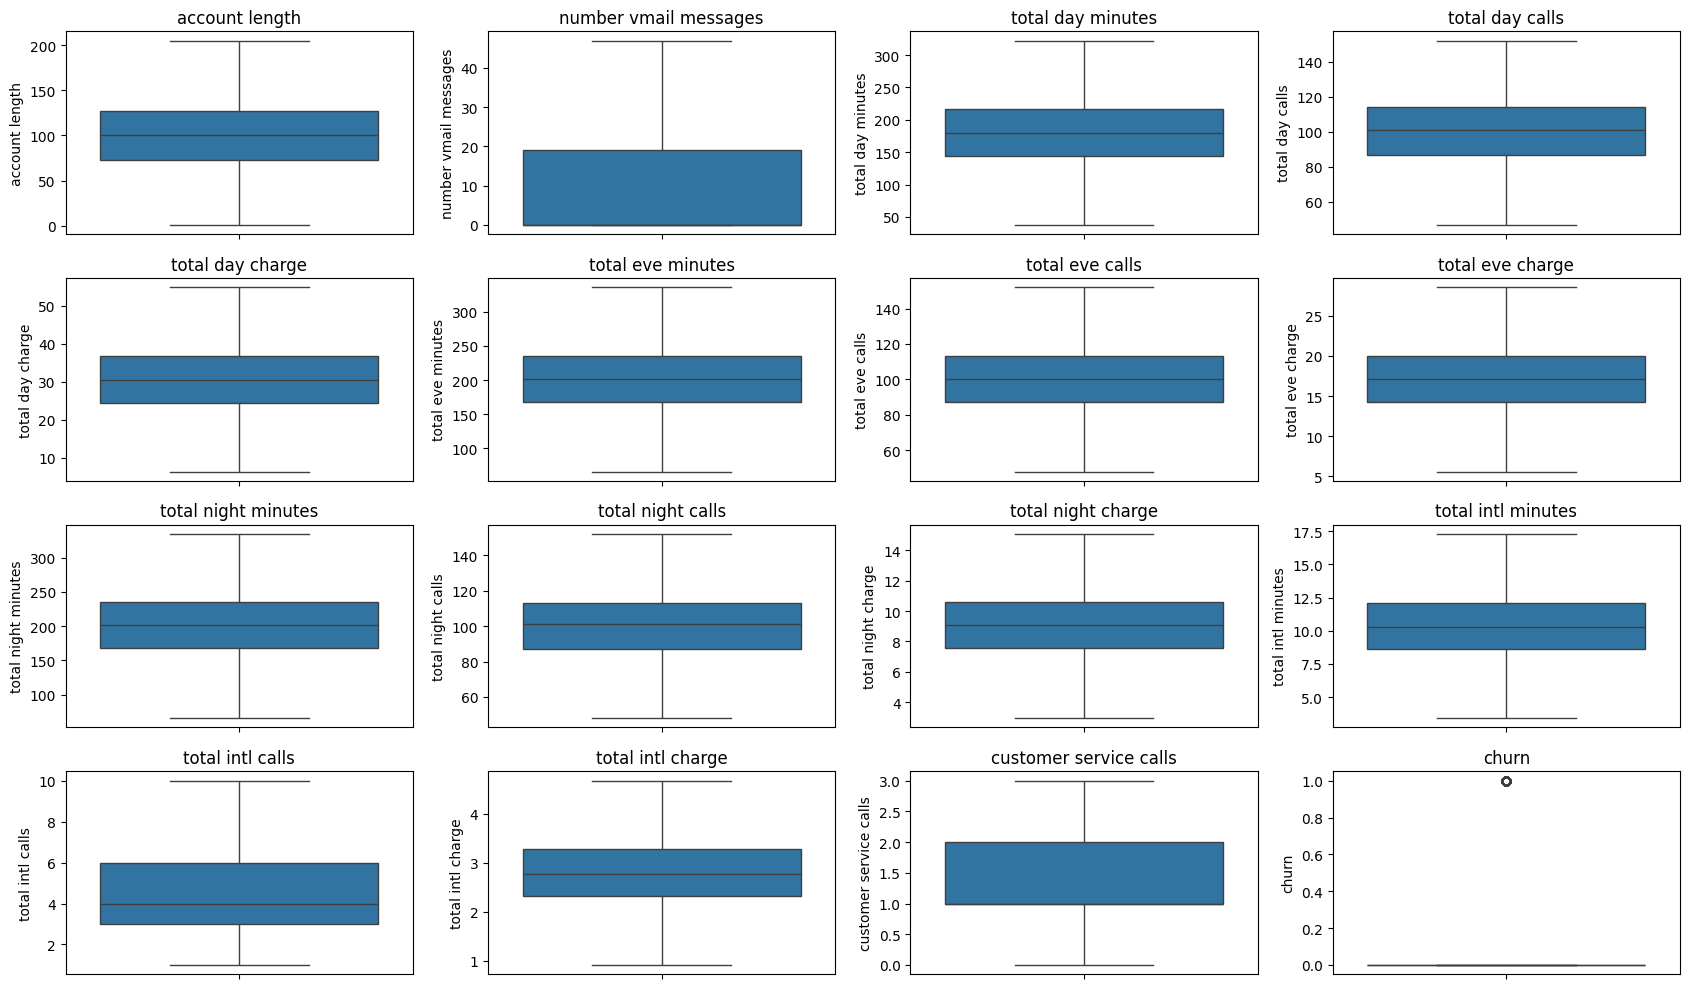

In [71]:
# Removing outliers using IQR
for col in numeric_columns:
    if col != 'churn':  # Excluding the target variable 'churn'
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        data = data[(data[col] >= Q1 - 1.5*IQR) & (data[col] <= Q3 + 1.5*IQR)]

create_boxplots(data, numeric_columns)



In [74]:
data['churn'].value_counts()

0    2486
1     303
Name: churn, dtype: int64

In [84]:
import sklearn
import imblearn

print(f"scikit-learn: {sklearn.__version__}")
print(f"imbalanced-learn: {imblearn.__version__}")


scikit-learn: 1.3.2
imbalanced-learn: 0.12.4


In [83]:
# SMOTE for class balancing
from imblearn.over_sampling import SMOTE

X = data.drop(columns=['churn'])
y = data['churn']
smote = SMOTE(k_neighbors=3, random_state=42)




# Apply SMOTE to generate synthetic samples
X_resampled, y_resampled = smote.fit_resample(X, y)

# Convert the resampled data back to a DataFrame
data_resampled = pd.DataFrame(X_resampled, columns=X.columns)
data_resampled['churn'] = y_resampled
y_resampled.value_counts()

from imblearn.over_sampling import SMOTE




AttributeError: 'NoneType' object has no attribute 'split'

In [82]:
!pip install threadpoolctl==3.1.0 